<a href="https://colab.research.google.com/github/cristian0527/Wildfire-Prediction-Model/blob/main/MATH244_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import lasso_path
from sklearn.compose import make_column_transformer
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.linear_model import ElasticNet, ElasticNetCV

In [3]:
wildfires_cleaned = pd.read_csv('../data/wildfires_clean2025.csv')

In [4]:
wildfires_cleaned.columns

Index(['...1', 'latitude', 'longitude', 'datetime', 'Wildfire', 'pr', 'rmax',
       'rmin', 'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000',
       'erc', 'etr', 'pet', 'vpd', 'region'],
      dtype='object')

In [5]:
wildfires_cleaned['Wildfire'].value_counts()

Wildfire
No     12103
Yes     6408
Name: count, dtype: int64

In [6]:
california = wildfires_cleaned[
    (wildfires_cleaned['latitude'] >= 32.5) & (wildfires_cleaned['latitude'] <= 42.0) &
    (wildfires_cleaned['longitude'] >= -124.5) & (wildfires_cleaned['longitude'] <= -114.0)
]

print(california.shape[0])  # row count

10038


In [7]:
california['Wildfire'].value_counts()

Wildfire
Yes    5194
No     4844
Name: count, dtype: int64

In [8]:
# Fitting a lasso linear regression to identify important and unimportant features
# Cross referrence with EDA -> R outputs

california_wildfires = california[california['Wildfire'] == 'Yes'].copy()

In [9]:
california_wildfires.columns

Index(['...1', 'latitude', 'longitude', 'datetime', 'Wildfire', 'pr', 'rmax',
       'rmin', 'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000',
       'erc', 'etr', 'pet', 'vpd', 'region'],
      dtype='object')

In [10]:
X = california_wildfires[['vpd', 'tmmx', 'pr', 'fm100', 'rmin', 'vs', 'srad']]
y = california_wildfires['bi']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# LASSO 10-fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=67)

lasso_cv_tune = LassoCV(cv=kf, random_state=12673, max_iter=10000)
lasso_cv_tune.fit(X, y)
print("Best alpha:", lasso_cv_tune.alpha_)

Best alpha: 0.5083949442271368


In [12]:
pipeline = Pipeline([
    ('preprocessor', StandardScaler()),
    ('model', Lasso(alpha=0.508, max_iter=10000))
])

In [13]:
cv_lasso = cross_validate(
    pipeline, X, y,
    cv=kf,
    scoring='neg_mean_squared_error',
    return_estimator=True
)

In [14]:
lasso_names = X.columns.tolist()

# df of coefficients across all 10 folds
coef_lasso = pd.DataFrame(
    [est.named_steps['model'].coef_ for est in cv_lasso['estimator']],
    columns=lasso_names
)

coef_lasso

,vpd,tmmx,pr,fm100,rmin,vs,srad
0,0.050138,0.0,-1.946215,-10.131165,-11.651175,8.212473,3.649592
1,0.126387,0.0,-1.961649,-9.818971,-11.759677,8.200491,3.833684
2,0.229798,0.0,-1.804502,-9.775155,-11.899453,7.792212,3.588585
3,0.084227,0.0,-1.883421,-9.897183,-11.790626,7.873671,3.665988
4,0.000000,0.0,-1.826522,-10.053224,-11.823869,7.837376,3.444841
5,0.000000,-0.0,-1.744528,-9.741310,-12.189329,7.927248,3.737556
6,0.175041,0.0,-1.721641,-9.743151,-11.973006,7.945824,3.868561
7,0.000000,0.0,-1.857847,-9.781489,-12.053919,7.886664,3.589853
8,0.000000,0.0,-2.006646,-10.070668,-11.794020,7.996210,3.497308
9,0.011215,-0.0,-1.874767,-9.897578,-11.688277,7.746503,3.774256


In [15]:
print((coef_lasso == 0).sum(axis=1))

0    1
1    1
2    1
3    1
4    2
5    2
6    1
7    2
8    2
9    1
dtype: int64


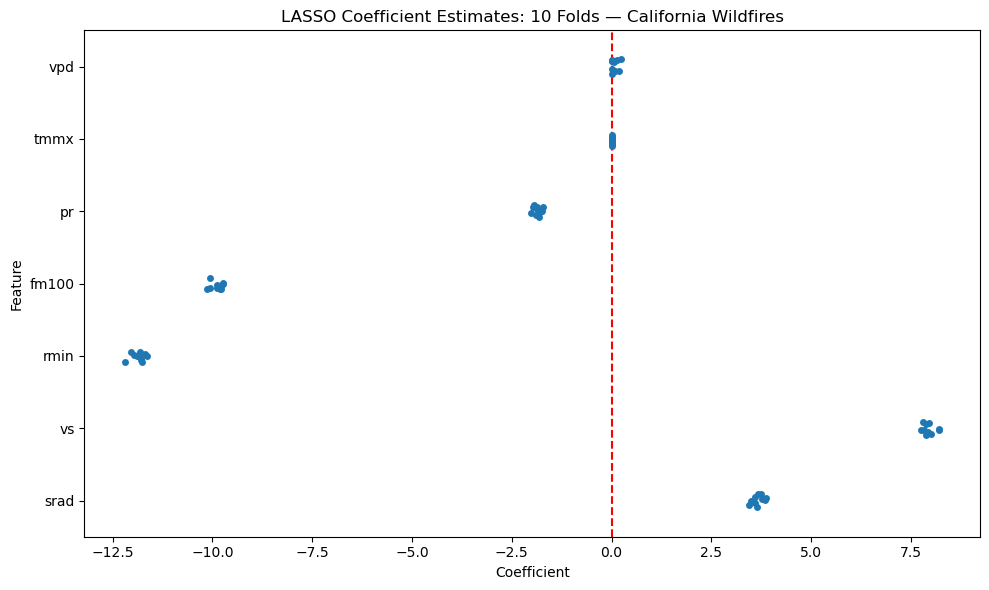

In [16]:
coef_long = coef_lasso.melt(var_name='Feature', value_name='Coefficient')

# strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(data=coef_long, x='Coefficient', y='Feature')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('LASSO Coefficient Estimates: 10 Folds — California Wildfires')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Practically all of our variables contributes to identifying BI score in California Wildfires

Except for tmmx and possibly removing vpd

In [17]:
import plotly.express as px
df = wildfires_cleaned[wildfires_cleaned['Wildfire'] == 'Yes']
fig = px.scatter_map(df, lat="latitude", lon="longitude", color="region", #size="car_hours",
                  color_continuous_scale=px.colors.cyclical.IceFire, size_max=15, zoom=10)
fig.show()